# Model Comparison

**Baseline model** vs **Data Augmentation model**

| | Model A | Model B |
|---|---|---|
| **Purpose** | Existing baseline | Data augmentation + focal loss |
| **File** | `cnn_transformer_0306_model.pt` | `CT_0313_Aug_001noise_01scale_focal_model.pt` |

In [2]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)
from scipy.signal import resample_poly, find_peaks, butter, filtfilt
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda:0


## 1. Configuration

In [3]:
DATASET_PATH        = '/home/binghin2/Myproject/Dataset/WESAD'
TEST_USERS          = ['S15', 'S16', 'S17']
TARGET_LABELS       = {1: 0, 2: 1, 3: 2}
N_FEATURES          = 10
DOWNSAMPLE_RATE     = 4
WINDOW_SIZE_SEC     = 60
TEST_STRIDE_SEC     = 60
LABEL_PURITY_THRESHOLD = 0.8
BATCH_SIZE          = 64
CLASS_NAMES         = ['Baseline', 'Stress', 'Amusement']

MODEL_A_PATH = 'Save_model/cnn_transformer_0306_model.pt'
MODEL_B_PATH = 'Save_model/CT_0313_Aug_001noise_01scale_focal_model.pt'
MODEL_A_NAME = 'Existing Baseline'
MODEL_B_NAME = 'Data Aug + Focal'

## 2. Data Loading & Preprocessing

In [4]:
def _to_2d_column(signal):
    signal = np.asarray(signal)
    return signal.reshape(-1, 1) if signal.ndim == 1 else signal

def _resample_signal(signal, orig_rate, target_rate):
    s = _to_2d_column(signal)
    if orig_rate == target_rate:
        return s
    return resample_poly(s, up=target_rate, down=orig_rate, axis=0)

def decompose_eda_scl_scr(eda, fs=4, cutoff_hz=0.05, order=2):
    eda_flat = np.asarray(eda).reshape(-1).astype(float)
    nyq = 0.5 * fs
    b, a = butter(order, cutoff_hz / nyq, btype='low')
    scl = np.copy(eda_flat) if len(eda_flat) <= (max(len(a), len(b)) * 3) else filtfilt(b, a, eda_flat)
    return scl.reshape(-1, 1), (eda_flat - scl).reshape(-1, 1)

def extract_bvp_features(bvp, orig_rate=64, target_rate=4):
    bvp_flat = np.asarray(bvp).flatten()
    peaks, _ = find_peaks(bvp_flat, distance=int(orig_rate * 0.3))
    times_orig = np.arange(len(bvp_flat)) / float(orig_rate)
    target_len = int(np.ceil(len(bvp_flat) * target_rate / float(orig_rate)))
    times_target = np.arange(target_len) / float(target_rate)
    if len(peaks) > 1:
        peak_times = times_orig[peaks]
        ibi = np.diff(peak_times)
        hr  = 60.0 / np.clip(ibi, 1e-6, None)
        peak_times = peak_times[1:]
        hr_c  = np.interp(times_target, peak_times, hr)
        ibi_c = np.interp(times_target, peak_times, ibi)
        hrv_c = pd.Series(ibi_c).rolling(window=target_rate*10, min_periods=1).std().fillna(0.0).values
    else:
        hr_c = ibi_c = hrv_c = np.zeros(target_len)
    return np.concatenate([hr_c.reshape(-1,1), ibi_c.reshape(-1,1), hrv_c.reshape(-1,1)], axis=1)

def load_and_preprocess_data(subject_path):
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    wrist = data['signal']['wrist']
    acc, bvp, eda, temp = wrist['ACC'], wrist['BVP'], wrist['EDA'], wrist['TEMP']
    labels = data['label']
    bvp_feat = extract_bvp_features(bvp, 64, DOWNSAMPLE_RATE)
    scl, scr  = decompose_eda_scl_scr(eda, fs=4)
    acc_d  = _resample_signal(acc,  32, DOWNSAMPLE_RATE)
    bvp_d  = _resample_signal(bvp,  64, DOWNSAMPLE_RATE)
    scl_d  = _resample_signal(scl,   4, DOWNSAMPLE_RATE)
    scr_d  = _resample_signal(scr,   4, DOWNSAMPLE_RATE)
    temp_d = _resample_signal(temp,  4, DOWNSAMPLE_RATE)
    lbl_ts = np.arange(len(labels)) / 700.0
    dat_ts = np.arange(len(acc_d))  / float(DOWNSAMPLE_RATE)
    idx = np.clip(np.searchsorted(lbl_ts, dat_ts, side='left'), 0, len(labels)-1)
    labels_d = labels[idx].astype(int)
    min_len  = min(len(acc_d), len(bvp_d), len(scl_d), len(scr_d), len(temp_d), len(bvp_feat), len(labels_d))
    features = np.concatenate([acc_d[:min_len], bvp_d[:min_len], scl_d[:min_len],
                                scr_d[:min_len], temp_d[:min_len], bvp_feat[:min_len]], axis=1)
    features = StandardScaler().fit_transform(features)
    return features, labels_d[:min_len]

def create_windows(features, labels, stride_sec):
    ws  = WINDOW_SIZE_SEC * DOWNSAMPLE_RATE
    st  = max(1, int(stride_sec * DOWNSAMPLE_RATE))
    X, y = [], []
    for i in range(0, len(features) - ws + 1, st):
        wl = labels[i:i+ws].astype(int)
        counts = np.bincount(wl)
        if counts.size == 0: continue
        dominant = int(counts.argmax())
        if dominant in TARGET_LABELS and counts[dominant]/float(ws) >= LABEL_PURITY_THRESHOLD:
            X.append(features[i:i+ws])
            y.append(TARGET_LABELS[dominant])
    return np.array(X), np.array(y)

# --- Build TEST set ---
test_X, test_y = [], []
for user in TEST_USERS:
    path = os.path.join(DATASET_PATH, user, f'{user}.pkl')
    if os.path.exists(path):
        print(f'Loading TEST user: {user}...')
        feat, lbl = load_and_preprocess_data(path)
        Xu, yu = create_windows(feat, lbl, TEST_STRIDE_SEC)
        if Xu.size > 0:
            test_X.append(Xu); test_y.append(yu)

X_test = np.concatenate(test_X, axis=0)
y_test = np.concatenate(test_y, axis=0)
print(f'\nTest samples: {len(X_test)}, label dist: {np.bincount(y_test)}')

Loading TEST user: S15...
Loading TEST user: S16...
Loading TEST user: S17...

Test samples: 108, label dist: [57 33 18]


## 3. Model Architecture

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term) if d_model % 2 == 0 else torch.cos(position * div_term[:-1])
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class CNNTransformerModel(nn.Module):
    def __init__(self, input_dim, cnn_out_channels, cnn_kernel_size, cnn_pool_size,
                 d_model, nhead, dim_feedforward, nlayers, output_dim, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, cnn_out_channels, kernel_size=cnn_kernel_size, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(cnn_pool_size)
        self.conv2 = nn.Conv1d(cnn_out_channels, cnn_out_channels, kernel_size=cnn_kernel_size, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(cnn_pool_size)
        self.cnn_to_transformer = nn.Linear(cnn_out_channels, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.transpose(1, 2)
        x = self.pos_encoder(self.cnn_to_transformer(x))
        x = self.transformer_encoder(x)
        return self.fc(x[:, -1, :])

def load_model_from_checkpoint(path):
    ckpt = torch.load(path, map_location=device)
    m = CNNTransformerModel(
        input_dim       = ckpt['n_features'],
        cnn_out_channels= ckpt['cnn_out_channels'],
        cnn_kernel_size = ckpt['cnn_kernel_size'],
        cnn_pool_size   = ckpt['cnn_pool_size'],
        d_model         = ckpt['d_model'],
        nhead           = ckpt['nhead'],
        dim_feedforward = ckpt['dim_feedforward'],
        nlayers         = ckpt['nlayers'],
        output_dim      = ckpt['output_dim'],
        dropout         = 0.0,   # eval mode: dropout 비활성화
    )
    m.load_state_dict(ckpt['model_state_dict'])
    m.to(device).eval()
    return m

print('Model architecture defined.')

Model architecture defined.


## 4. Evaluation

In [6]:
class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

test_loader = DataLoader(SimpleDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

@torch.no_grad()
def evaluate(model):
    all_preds, all_labels = [], []
    for seqs, lbls in test_loader:
        seqs = seqs.to(device)
        preds = torch.argmax(model(seqs), dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())
    return np.array(all_labels), np.array(all_preds)

# --- Load & evaluate both models ---
model_a = load_model_from_checkpoint(MODEL_A_PATH)
labels_a, preds_a = evaluate(model_a)
print(f'[Model A] Loaded: {MODEL_A_PATH}')

model_b = load_model_from_checkpoint(MODEL_B_PATH)
labels_b, preds_b = evaluate(model_b)
print(f'[Model B] Loaded: {MODEL_B_PATH}')

/tmp/ipykernel_17364/1130518922.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=device)


[Model A] Loaded: Save_model/cnn_transformer_0306_model.pt
[Model B] Loaded: Save_model/CT_0313_Aug_001noise_01scale_focal_model.pt


## 5. Results Comparison

In [7]:
def compute_metrics(true, pred):
    acc      = accuracy_score(true, pred) * 100
    macro_f1 = f1_score(true, pred, average='macro',    zero_division=0)
    per_f1   = f1_score(true, pred, average=None,       zero_division=0, labels=[0,1,2])
    return acc, macro_f1, per_f1

acc_a, mf1_a, pf1_a = compute_metrics(labels_a, preds_a)
acc_b, mf1_b, pf1_b = compute_metrics(labels_b, preds_b)

# ── Summary table ──────────────────────────────────────────
col_w = 28
print('\n' + '='*72)
print(f"{'Metric':<22} {'Model A':>{col_w}} {'Model B':>{col_w}}")
print(f"{'':22} {MODEL_A_NAME:>{col_w}} {MODEL_B_NAME:>{col_w}}")
print('-'*72)
print(f"{'Accuracy (%)' :<22} {acc_a:>{col_w}.2f} {acc_b:>{col_w}.2f}")
print(f"{'Macro F1'     :<22} {mf1_a:>{col_w}.4f} {mf1_b:>{col_w}.4f}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  F1 {name:<18} {pf1_a[i]:>{col_w}.4f} {pf1_b[i]:>{col_w}.4f}")
print('='*72)

# ── Per-model classification report ────────────────────────
for name, true, pred in [(MODEL_A_NAME, labels_a, preds_a), (MODEL_B_NAME, labels_b, preds_b)]:
    print(f'\n[{name}]')
    print(classification_report(true, pred, target_names=['baseline','stress','amusement'], zero_division=0))


Metric                                      Model A                      Model B
                                  Existing Baseline             Data Aug + Focal
------------------------------------------------------------------------
Accuracy (%)                                  72.22                        53.70
Macro F1                                     0.5928                       0.5279
  F1 Baseline                                 0.8000                       0.5000
  F1 Stress                                   0.8451                       0.7887
  F1 Amusement                                0.1333                       0.2951

[Existing Baseline]
              precision    recall  f1-score   support

    baseline       0.79      0.81      0.80        57
      stress       0.79      0.91      0.85        33
   amusement       0.17      0.11      0.13        18

    accuracy                           0.72       108
   macro avg       0.58      0.61      0.59       108
weighted 

## 6. Visualization

/tmp/ipykernel_17364/3738771984.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


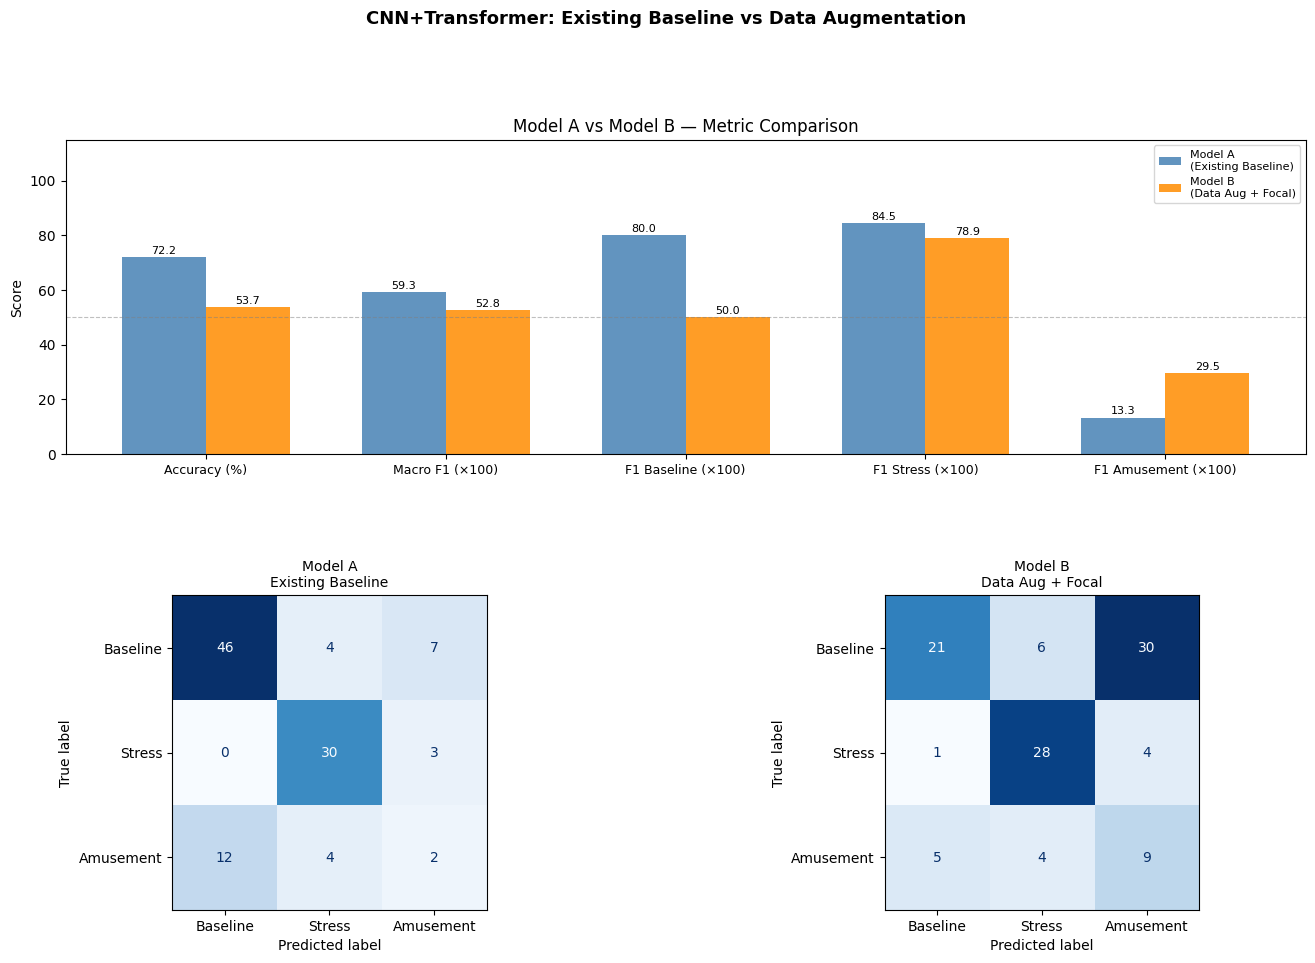

Figure saved to Save_model/model_comparison.png


In [8]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Bar chart: Accuracy & Macro F1 ──────────────────────────
ax0 = fig.add_subplot(gs[0, :])
metrics      = ['Accuracy (%)', 'Macro F1 (×100)', 'F1 Baseline (×100)', 'F1 Stress (×100)', 'F1 Amusement (×100)']
vals_a = [acc_a, mf1_a*100, pf1_a[0]*100, pf1_a[1]*100, pf1_a[2]*100]
vals_b = [acc_b, mf1_b*100, pf1_b[0]*100, pf1_b[1]*100, pf1_b[2]*100]
x = np.arange(len(metrics))
w = 0.35
bars_a = ax0.bar(x - w/2, vals_a, w, label=f'Model A\n({MODEL_A_NAME})', color='steelblue',  alpha=0.85)
bars_b = ax0.bar(x + w/2, vals_b, w, label=f'Model B\n({MODEL_B_NAME})', color='darkorange', alpha=0.85)
for bar in [*bars_a, *bars_b]:
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
ax0.set_xticks(x)
ax0.set_xticklabels(metrics, fontsize=9)
ax0.set_ylim(0, 115)
ax0.set_ylabel('Score')
ax0.set_title('Model A vs Model B — Metric Comparison')
ax0.legend(loc='upper right', fontsize=8)
ax0.axhline(50, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

# ── Confusion matrices ───────────────────────────────────────
for ax, true, pred, title in [
    (fig.add_subplot(gs[1, 0]), labels_a, preds_a, f'Model A\n{MODEL_A_NAME}'),
    (fig.add_subplot(gs[1, 1]), labels_b, preds_b, f'Model B\n{MODEL_B_NAME}'),
]:
    cm = confusion_matrix(true, pred, labels=[0,1,2])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Blues', values_format='d', colorbar=False
    )
    ax.set_title(title, fontsize=10)

plt.suptitle('CNN+Transformer: Existing Baseline vs Data Augmentation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Save_model/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to Save_model/model_comparison.png')

## 7. Additional Comparison: Baseline vs Focal-only

Compare `cnn_transformer_0306_model.pt` and `CT_0313_focal_model.pt` using confusion matrices.

[Baseline] Loaded: Save_model/cnn_transformer_0306_model.pt
[Focal only] Loaded: Save_model/CT_0313_focal_model.pt

Metric                               Baseline             Focal only
------------------------------------------------------------------------
Accuracy (%)                            72.22                  76.85
Macro F1                               0.5928                 0.7312


/tmp/ipykernel_17364/1130518922.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=device)


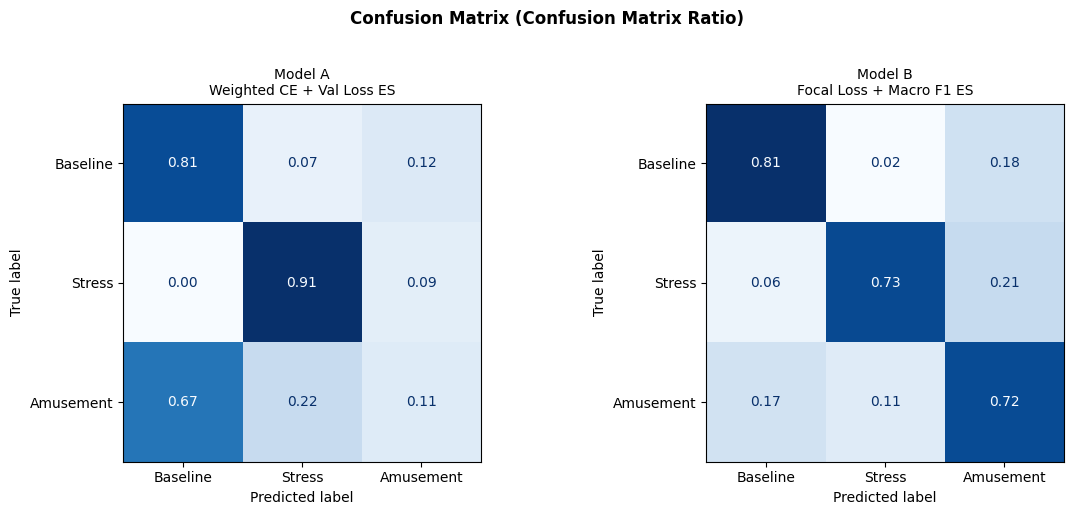

In [14]:
# Compare baseline model vs focal-only model
MODEL_BASELINE_PATH = 'Save_model/cnn_transformer_0306_model.pt'
MODEL_FOCAL_ONLY_PATH = 'Save_model/CT_0313_focal_model.pt'
MODEL_BASELINE_NAME = 'Weighted CE + Val Loss ES'
MODEL_FOCAL_ONLY_NAME = 'Focal Loss + Macro F1 ES'

model_base = load_model_from_checkpoint(MODEL_BASELINE_PATH)
labels_base, preds_base = evaluate(model_base)
print(f'[Baseline] Loaded: {MODEL_BASELINE_PATH}')

model_focal = load_model_from_checkpoint(MODEL_FOCAL_ONLY_PATH)
labels_focal, preds_focal = evaluate(model_focal)
print(f'[Focal only] Loaded: {MODEL_FOCAL_ONLY_PATH}')

acc_base, mf1_base, _ = compute_metrics(labels_base, preds_base)
acc_focal, mf1_focal, _ = compute_metrics(labels_focal, preds_focal)

print('\n' + '='*72)
print(f"{'Metric':<22} {'Baseline':>22} {'Focal only':>22}")
print('-'*72)
print(f"{'Accuracy (%)' :<22} {acc_base:>22.2f} {acc_focal:>22.2f}")
print(f"{'Macro F1'     :<22} {mf1_base:>22.4f} {mf1_focal:>22.4f}")
print('='*72)

fig2, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true, pred, title in [
    (axes[0], labels_base, preds_base, f'Model A\n{MODEL_BASELINE_NAME}'),
    (axes[1], labels_focal, preds_focal, f'Model B\n{MODEL_FOCAL_ONLY_NAME}'),
]:
    cm = confusion_matrix(true, pred, labels=[0, 1, 2]).astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_ratio = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)

    ConfusionMatrixDisplay(cm_ratio, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Blues', values_format='.2f', colorbar=False
    )
    ax.set_title(title, fontsize=10)

plt.suptitle('Confusion Matrix (Confusion Matrix Ratio)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()